# Импорт библиотек

In [3]:
import sys
import os

sys.path.append(os.path.abspath('lib'))

from filters_features_utils import FeatureSelector, FeatureSelectorCV, get_best_xgboost_features_names
from preprocessing_pipeline import create_combined_pipeline
from test_models import run_models_regressions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

# Считывание данных

In [5]:
df = pd.read_csv('data/processed.csv')
df.shape

(999, 213)

# Очистка таргета от выбросов

(997, 213)


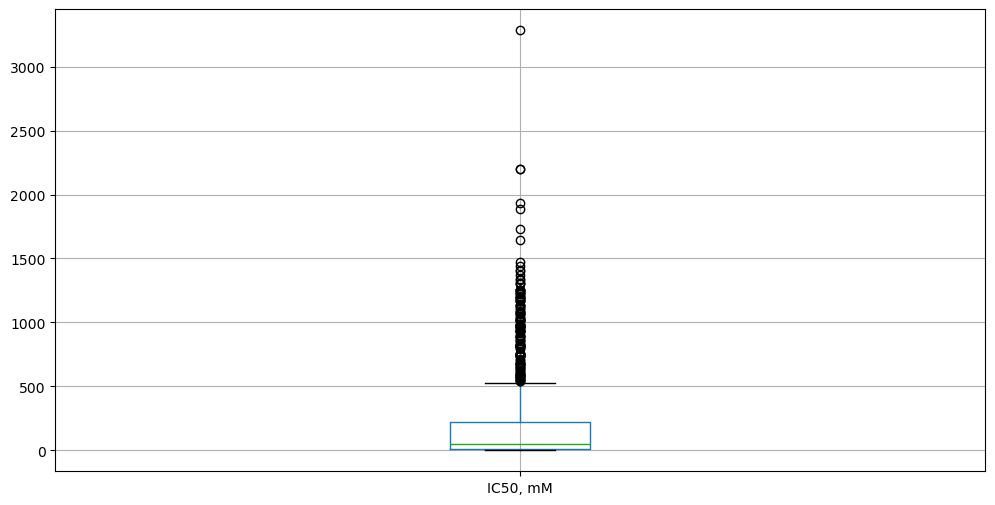

In [7]:
df = df[df['IC50, mM'] < 4000]
print(df.shape)
df.boxplot(column=['IC50, mM'], figsize=(12, 6))
plt.show()

# Удаление невалидных экземляров

In [8]:
matching_instances = df[df['IC50, mM'] == df['CC50, mM']]
print(len(matching_instances.index))
df.drop(index=matching_instances.index, inplace=True)

131


# Подготовка данных для эксперемента

In [10]:
combined_pipeline = create_combined_pipeline()
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y1 = df['IC50, mM']
y2 = df['CC50, mM']
y3 = df['SI']
X_transformed = combined_pipeline.fit_transform(X)
df = pd.concat([X_transformed, y1, y2, y3], axis=1)

In [11]:
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = df['IC50, mM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (692, 98), (692,)
Test dataset size: (174, 98), (174,)


# Эксперемент с моделями

In [19]:
run_models_regressions(X_train, X_test, y_train, y_test)

,Model,Mean Absolute Error,R2 Score
2,Random Forest,109.03,0.51
9,Krr,107.57,0.48
5,LightGBM,109.54,0.46
6,CatBoost,108.72,0.46
7,HistGradientBoosting,109.83,0.45
4,Gradient Boosting,113.80,0.43
1,KNeighbors,110.94,0.42
3,XGBoost,109.60,0.42
8,AdaBoost,136.32,0.26
0,Decision Tree,130.37,0.10


# Фильтрация признаков

In [32]:
xgboost_features = get_best_xgboost_features_names(X_train, y_train, 50)

In [34]:
featureSelectorCV = FeatureSelectorCV()
featureSelectorCV.fit(X_train, y_train)

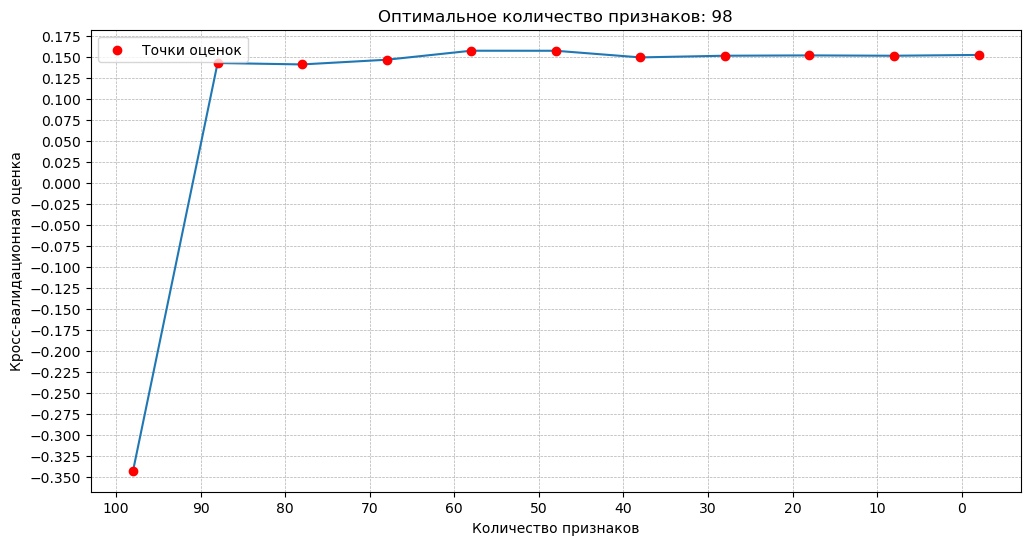

In [35]:
featureSelectorCV.plot_result()

In [36]:
model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_seed=42, verbose=0)
featureSelector = FeatureSelector(model=model, start_index=5, step=5)

In [37]:
featureSelector.calculate_k_best(X_train, X_test, y_train, y_test)

K-Best Progress: 100%|██████████| 19/19 [00:05<00:00,  3.52it/s]


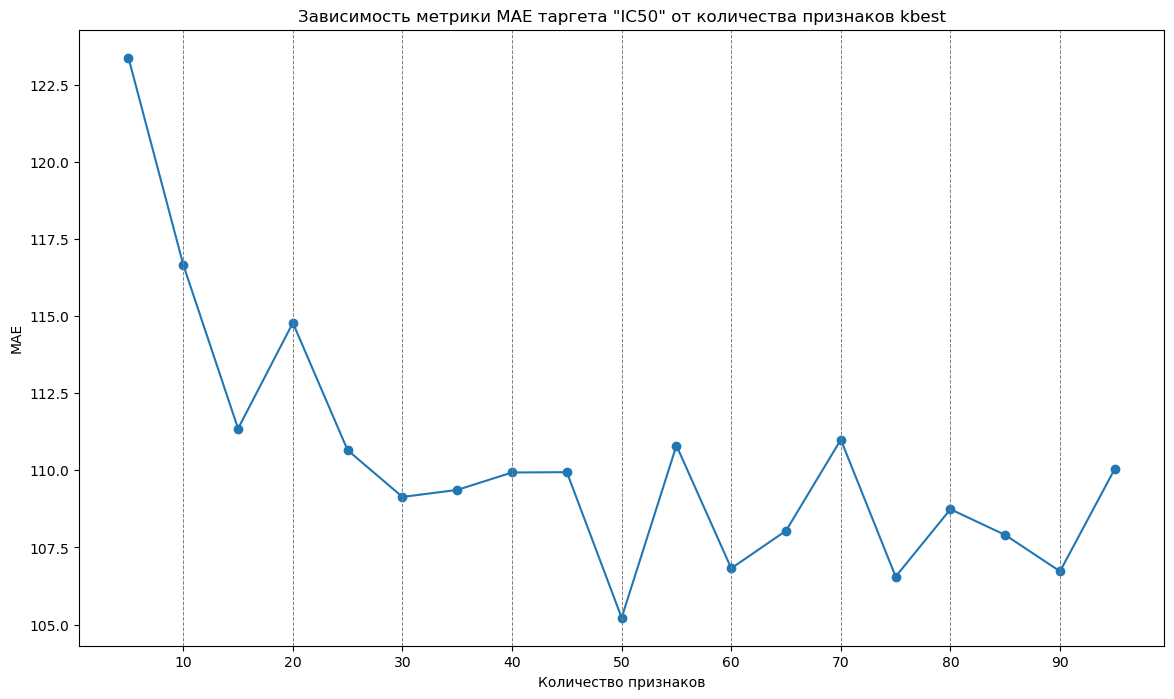

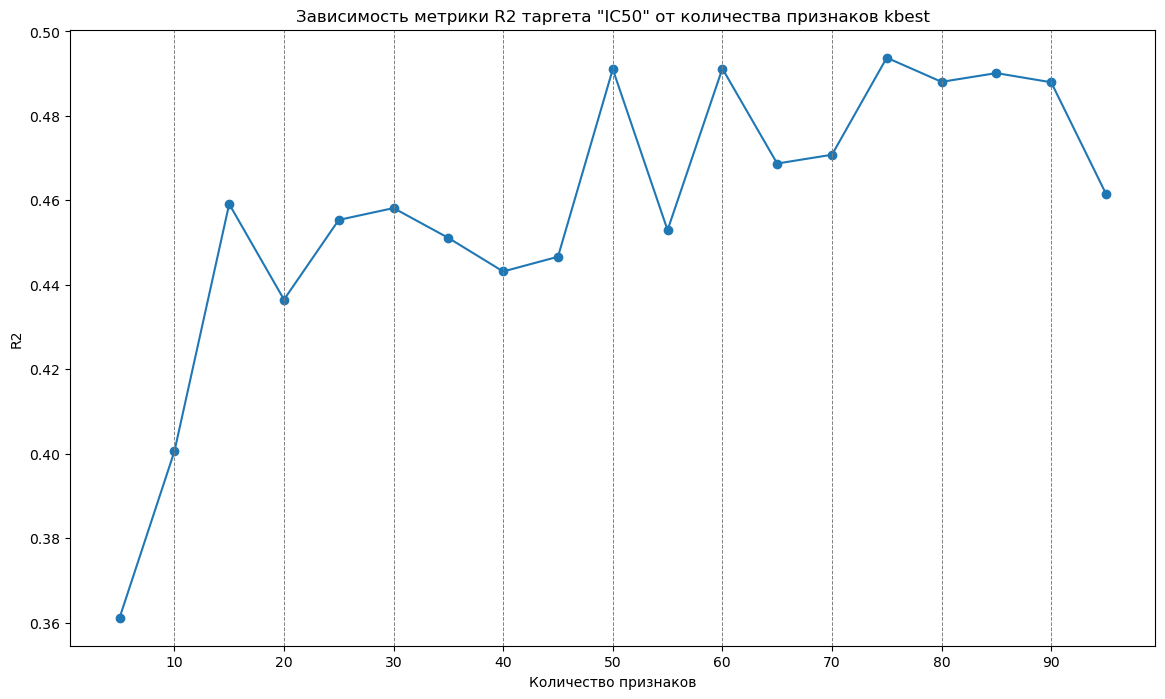

In [38]:
featureSelector.draw_selection(featureSelector.kbest_mae_scores, 'MAE', 'IC50', 'kbest')
featureSelector.draw_selection(featureSelector.kbest_r2_scores, 'R2', 'IC50', 'kbest')

In [39]:
featureSelector.calculate_rfe(X_train, X_test, y_train, y_test)

RFE Progress: 100%|██████████| 19/19 [01:24<00:00,  4.47s/it]


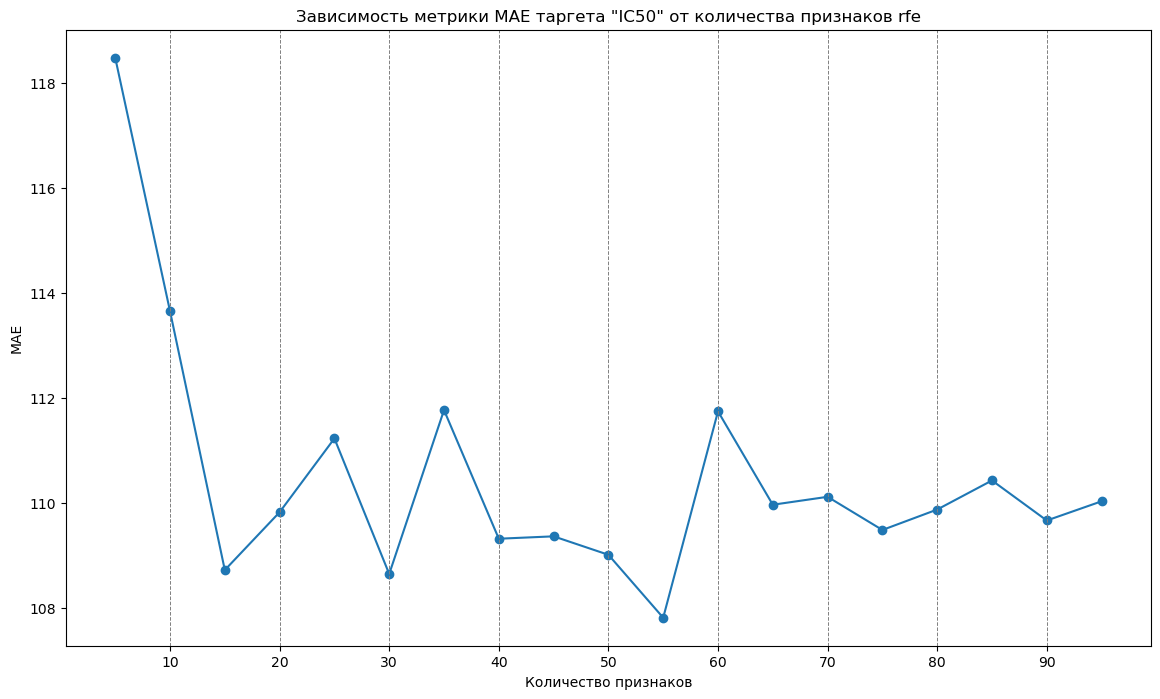

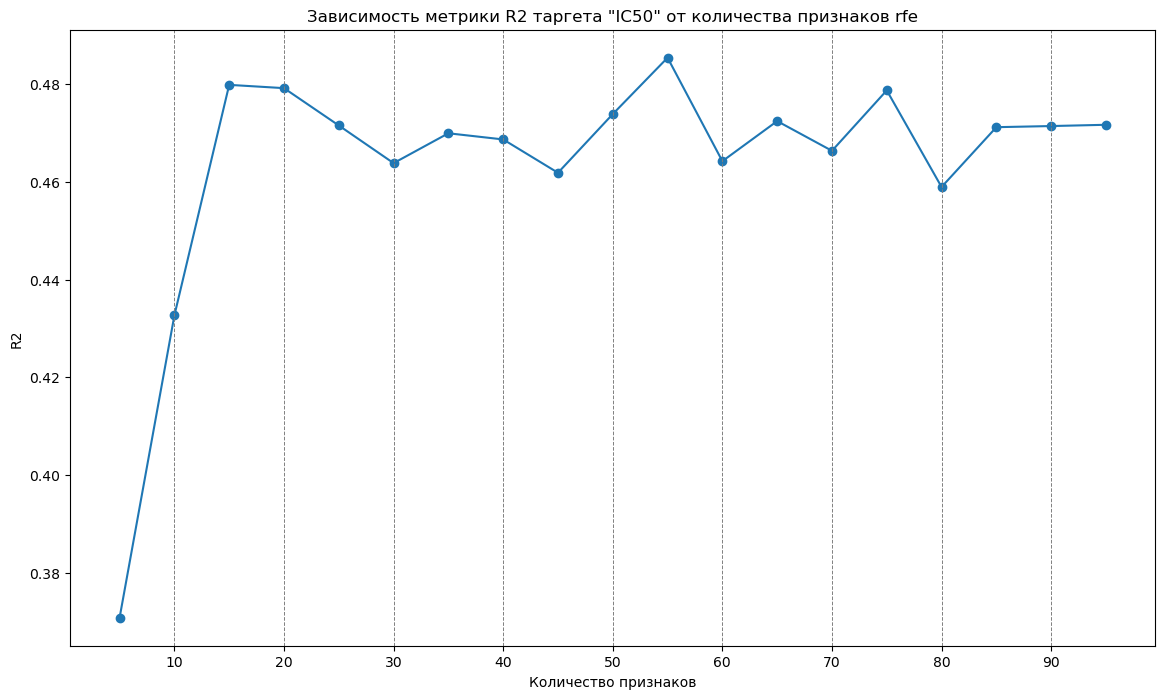

In [40]:
featureSelector.draw_selection(featureSelector.rfe_mae_scores, 'MAE', 'IC50', 'rfe')
featureSelector.draw_selection(featureSelector.rfe_r2_scores, 'R2', 'IC50', 'rfe')

In [41]:
featureSelector.print_kbest_result()

mae: 106.55297597121793
r2: 0.49377760205364685
Index(['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed',
       'SPS', 'MaxPartialCharge', 'HallKierAlpha', 'TPSA', 'NHOHCount',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumAromaticHeterocycles', 'NumAromaticRings', 'NumRotatableBonds',
       'MolLogP', 'fr_Al_COO', 'fr_Al_OH', 'fr_ArN', 'fr_Ar_N', 'fr_Ar_OH',
       'fr_C_O', 'fr_C_S', 'fr_Imine', 'fr_NH1', 'fr_NH2', 'fr_Ndealkylation1',
       'fr_Ndealkylation2', 'fr_alkyl_carbamate', 'fr_alkyl_halide',
       'fr_amidine', 'fr_aniline', 'fr_azo', 'fr_bicyclic', 'fr_epoxide',
       'fr_ester', 'fr_ether', 'fr_furan', 'fr_guanido', 'fr_halogen',
       'fr_hdrzone', 'fr_imidazole', 'fr_ketone_Topliss', 'fr_methoxy',
       'fr_morpholine', 'fr_nitro', 'fr_nitro_arom', 'fr_oxime',
       'fr_piperdine', 'fr_piperzine', 'fr_priamide', 'fr_pyridine',
       'fr_quatN', 'fr_sulfide', 'fr_sulfone', 'fr_thiazole', 'fr_thiophene',
       'fr_unbrc

In [42]:
featureSelector.print_rfe_result()

mae: 107.80684385810505
r2: 0.4854219371318812
Index(['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed',
       'SPS', 'MaxPartialCharge', 'HallKierAlpha', 'TPSA', 'NHOHCount',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumAromaticHeterocycles', 'NumAromaticRings', 'NumRotatableBonds',
       'MolLogP', 'fr_Ar_OH', 'fr_C_O', 'fr_Imine', 'fr_NH0', 'fr_NH1',
       'fr_NH2', 'fr_Ndealkylation2', 'fr_aryl_methyl', 'fr_benzene',
       'fr_bicyclic', 'fr_ether', 'fr_ketone_Topliss', 'fr_methoxy',
       'fr_piperdine', 'fr_priamide', 'fr_sulfide', 'fr_sulfonamd',
       'fr_thiazole', 'fr_thiophene', 'fr_urea', 'EState_VSA_median',
       'EState_VSA_min', 'EState_VSA_variation', 'VSA_EState_median',
       'VSA_EState_min', 'VSA_EState_variation', 'PEOE_VSA_median',
       'PEOE_VSA_variation', 'SMR_VSA_median', 'SMR_VSA_variation',
       'SlogP_VSA_median', 'SlogP_VSA_variation', 'Chi_prod', 'Chi_variation',
       'BCUT2D_prod', 'BCUT2D_variati

In [43]:
common_selected_features, combined_selected_features = featureSelector.get_selected_features()

# Эксперемент с различными моделями

In [44]:
run_models_regressions(X_train, X_test, y_train, y_test)

,Model,Mean Absolute Error,R2 Score
2,Random Forest,109.03,0.51
9,Krr,107.57,0.48
5,LightGBM,109.54,0.46
6,CatBoost,108.72,0.46
7,HistGradientBoosting,109.83,0.45
4,Gradient Boosting,113.80,0.43
1,KNeighbors,110.94,0.42
3,XGBoost,109.60,0.42
8,AdaBoost,136.32,0.26
0,Decision Tree,130.37,0.10


In [45]:
run_models_regressions(X_train[xgboost_features], X_test[xgboost_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,Random Forest,110.21,0.49
7,CatBoost,108.37,0.49
6,LightGBM,109.12,0.46
8,HistGradientBoosting,110.59,0.45
5,Gradient Boosting,115.04,0.42
4,XGBoost,111.77,0.41
10,Krr,109.26,0.38
2,KNeighbors,116.24,0.37
0,Linear Regression,128.43,0.35
9,AdaBoost,142.59,0.30


In [46]:
run_models_regressions(X_train[featureSelectorCV.best_features_names], X_test[featureSelectorCV.best_features_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,Random Forest,109.86,0.50
10,Krr,107.57,0.48
7,CatBoost,109.42,0.47
6,LightGBM,109.54,0.46
8,HistGradientBoosting,109.83,0.45
5,Gradient Boosting,114.76,0.43
2,KNeighbors,110.94,0.42
4,XGBoost,109.43,0.42
0,Linear Regression,124.86,0.39
9,AdaBoost,140.98,0.29


In [47]:
run_models_regressions(X_train[featureSelector.kbest_best_feature_names], X_test[featureSelector.kbest_best_feature_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,Random Forest,108.15,0.51
7,CatBoost,106.55,0.49
6,LightGBM,110.47,0.46
8,HistGradientBoosting,108.80,0.46
10,Krr,105.05,0.46
4,XGBoost,108.08,0.43
5,Gradient Boosting,109.33,0.42
2,KNeighbors,112.87,0.41
0,Linear Regression,127.15,0.36
9,AdaBoost,131.17,0.33


In [48]:
run_models_regressions(X_train[featureSelector.rfe_best_feature_names], X_test[featureSelector.rfe_best_feature_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,Random Forest,110.77,0.49
7,CatBoost,107.81,0.49
6,LightGBM,109.88,0.47
8,HistGradientBoosting,109.73,0.45
10,Krr,109.10,0.45
2,KNeighbors,112.21,0.42
5,Gradient Boosting,115.43,0.42
0,Linear Regression,123.27,0.41
4,XGBoost,111.14,0.41
9,AdaBoost,146.53,0.29


# Подбор гиперпараметров

In [133]:
param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['friedman_mse', 'absolute_error', 'poisson'],
    'max_samples': uniform(0.1, 0.9),
}
random_search = RandomizedSearchCV(
    estimator= RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=500,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Лучшие параметры:", best_params)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.3f}")
print(f"R2 Score: {r2:.3f}")

Лучшие параметры: {'criterion': 'poisson', 'max_depth': 16, 'max_features': 'log2', 'max_samples': 0.9743794218109456, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 241}
Mean Absolute Error: 107.576
R2 Score: 0.502


In [136]:
best_model = RandomForestRegressor(
    criterion='poisson',
    max_depth=16,
    max_features='log2',
    max_samples=0.97,
    min_samples_leaf=1,
    min_samples_split=4,
    n_estimators=241,
    random_state=42,
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.3f}')
print(f'R2 Score: {r2:.3f}')

Mean Absolute Error: 106.946
R2 Score: 0.510
